# 피마 인디언 당뇨병 예측 데이터세트
* 당뇨병 여부 판단하는 머신러닝 예측 모델 수립하고 평가 지표 적용해보자
* 북아메리카 피마 지역 원주민의 2형 당뇨병 결과 데이터임
* 데이터 세트 피처
  * Pregnancies = 임신 횟수
  * Glucose = 포도당 부차 검사 수치
  * BoolPressure = 혈압
  * SkinThickness = 팔 삼두근 뒤쪽 피하지방 측정값
  * Insulin = 혈청 인슐린
  * BMI = 체질량지수
  * DiabetesPedigreeFunction = 당뇨 내력 가중치 값
  * Age = 나이
  * Outcome = 클래스 결정값. 0 or 1

In [23]:
### 라이브러리 임포트

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import Binarizer

In [25]:
### 사용할 함수
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    
    print('오차행렬 : ')
    print(confusion)
    
    print('정확도 : {0:.4f} , 정밀도 : {1:.4f} , 재현율 : {2:.4f} , F1 : {3:.4f}, AUC : {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))
    
def precision_recall_curve_plot(y_test, pred_proba_c1):
    #threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)
    #x축을 threshold값으로, y축을 정밀도, 재현율 값으로 각각 plot 수행. 정밀도는 점선
    plt.figure(figsize=(8, 6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary], label='recall')
    #threshold값 x축의 스케일을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    #각 축 라벨과 범례, 그리드 설정
    plt.xlabel("Threshold value")
    plt.ylabel("Precision and Recall Value")
    plt.legend()
    plt.grid()
    plt.show()

def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
        custom_predict = binarizer.transform(pred_proba_c1)
        print("임곗값 : ", custom_threshold)
        get_clf_eval(y_test, custom_predict, pred_proba_c1)

In [4]:
#데이터 로딩 및 outcome 개수 확인

diabets_data = pd.read_csv('../kaggle/pima_indians_diabets/diabetes.csv')
print(diabets_data['Outcome'].value_counts())
diabets_data.head(3)

0    500
1    268
Name: Outcome, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [5]:
# 피처 타입과 null 개수 확인

diabets_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
#로지스틱 회귀로 예측 모델 생성 ~ 예측 평가 수행

x = diabets_data.iloc[:, :-1]
y = diabets_data.iloc[:, -1]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=156, stratify=y)

lr_clf = LogisticRegression()
lr_clf.fit(x_train, y_train)
pred = lr_clf.predict(x_test)
pred_proba = lr_clf.predict_proba(x_test)[:, 1]

get_clf_eval(y_test, pred, pred_proba)

오차행렬 : 
[[88 12]
 [23 31]]
정확도 : 0.7727 , 정밀도 : 0.7209 , 재현율 : 0.5741 , F1 : 0.6392, AUC : 0.7919


C:\Users\lumos\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


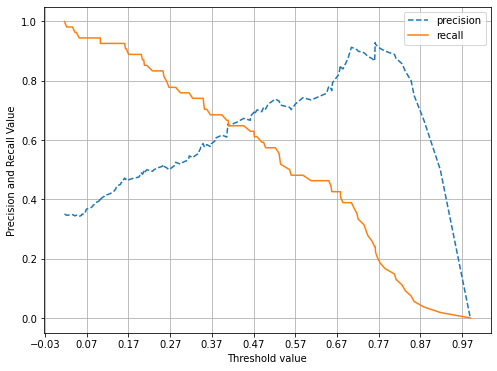

In [13]:
### 전체 데이터의 65프로가 Negative이므로 정확도보다 재현율에 초점 맞춰 변경해보기

#정밀도 재현율 곡선을 보고 임곗값 별 정밀도와 재현율 값의 변화 확인하자
pred_proba_c1 = lr_clf.predict_proba(x_test)[:, 1]
precision_recall_curve_plot(y_test, pred_proba_c1)

In [14]:
#정밀도와 재현율이 0.42 정도면 균형 맞추나, 지표가 0.7이 안되게 낮음
#임계값을 인위적으로 조작하기 전에 값의 분포도부터 살펴보자
diabets_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [16]:
#min = 0인 경우가 많음 -> 0값의 건수 및 전체 데이터 건수 대비 몇 퍼센트 비율로 존재하는지 확인하자

#0값을 검사할 피처명 리스트
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
#전체 데이터 건수
total_count = diabets_data['Glucose'].count()
#피처별로 반복하면서 데이터값이 0인 데이터 건수를 추출하고, 퍼센트 계산
for feature in zero_features:
    zero_count = diabets_data[diabets_data[feature] == 0][feature].count()
    print('{0} 0 건수는 {1}, 퍼센트는 {2:.2f}%'.format(feature, zero_count, 100*zero_count/total_count))

Glucose 0 건수는 5, 퍼센트는 0.65%
BloodPressure 0 건수는 35, 퍼센트는 4.56%
SkinThickness 0 건수는 227, 퍼센트는 29.56%
Insulin 0 건수는 374, 퍼센트는 48.70%
BMI 0 건수는 11, 퍼센트는 1.43%


In [18]:
# 0값을 평균값으로 대체
mean_zero_features = diabets_data[zero_features].mean()
diabets_data[zero_features] = diabets_data[zero_features].replace(0, mean_zero_features)

#변환값에 대해 피처 스케일링 적용해 변환
x = diabets_data.iloc[:, :-1]
y = diabets_data.iloc[:, -1]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=156, stratify=y)

lr_clf = LogisticRegression()
lr_clf.fit(x_train, y_train)
pred = lr_clf.predict(x_test)
pred_proba = lr_clf.predict_proba(x_test)[:, 1]

get_clf_eval(y_test, pred, pred_proba)

오차행렬 : 
[[90 10]
 [21 33]]
정확도 : 0.7987 , 정밀도 : 0.7674 , 재현율 : 0.6111 , F1 : 0.6804, AUC : 0.8433


In [26]:
#좀 더 성능 개선하기 위해, 분류 결정 임곗값을 변화시키며 재현율 성능 수치 개선 확인

thresholds = [0.3, 0.33, 0.36, 0.39, 0.42, 0.45, 0.48, 0.50]
pred_proba = lr_clf.predict_proba(x_test)
get_eval_by_threshold(y_test, pred_proba[:, 1].reshape(-1, 1), thresholds)

임곗값 :  0.3
오차행렬 : 
[[67 33]
 [11 43]]
정확도 : 0.7143 , 정밀도 : 0.5658 , 재현율 : 0.7963 , F1 : 0.6615, AUC : 0.8433
임곗값 :  0.33
오차행렬 : 
[[72 28]
 [12 42]]
정확도 : 0.7403 , 정밀도 : 0.6000 , 재현율 : 0.7778 , F1 : 0.6774, AUC : 0.8433
임곗값 :  0.36
오차행렬 : 
[[76 24]
 [15 39]]
정확도 : 0.7468 , 정밀도 : 0.6190 , 재현율 : 0.7222 , F1 : 0.6667, AUC : 0.8433
임곗값 :  0.39
오차행렬 : 
[[78 22]
 [16 38]]
정확도 : 0.7532 , 정밀도 : 0.6333 , 재현율 : 0.7037 , F1 : 0.6667, AUC : 0.8433
임곗값 :  0.42
오차행렬 : 
[[84 16]
 [18 36]]
정확도 : 0.7792 , 정밀도 : 0.6923 , 재현율 : 0.6667 , F1 : 0.6792, AUC : 0.8433
임곗값 :  0.45
오차행렬 : 
[[85 15]
 [18 36]]
정확도 : 0.7857 , 정밀도 : 0.7059 , 재현율 : 0.6667 , F1 : 0.6857, AUC : 0.8433
임곗값 :  0.48
오차행렬 : 
[[88 12]
 [19 35]]
정확도 : 0.7987 , 정밀도 : 0.7447 , 재현율 : 0.6481 , F1 : 0.6931, AUC : 0.8433
임곗값 :  0.5
오차행렬 : 
[[90 10]
 [21 33]]
정확도 : 0.7987 , 정밀도 : 0.7674 , 재현율 : 0.6111 , F1 : 0.6804, AUC : 0.8433


In [27]:
# 임곗값 0.48이 가장 좋아보임
binarizer = Binarizer(threshold=0.48)
pred_th_048 = binarizer.fit_transform(pred_proba[:, 1].reshape(-1, 1))
get_clf_eval(y_test, pred_th_048, pred_proba[:, 1])

오차행렬 : 
[[88 12]
 [19 35]]
정확도 : 0.7987 , 정밀도 : 0.7447 , 재현율 : 0.6481 , F1 : 0.6931, AUC : 0.8433
